In [12]:
from models.diffusion import Denoiser, DenoiserConfig, SigmaDistributionConfig
from models.actor_critic import ActorCritic, ActorCriticConfig, ActorCriticLossConfig
from omegaconf import DictConfig, OmegaConf
import yaml
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset
import random
from tqdm import tqdm

# Dataset

In [13]:
from supersuit import frame_skip_v0, resize_v1, frame_stack_v1, reshape_v0
import numpy as np

def get_env_from_id(id: str):
    if id == "boxing":
        from pettingzoo.atari import boxing_v2
        return boxing_v2.parallel_env
    
    else:
        raise ValueError(f"Environment {id} not found")

def env_fn(env_func):
    env = env_func(render_mode="rgb_array")
    env = frame_skip_v0(env, num_frames=4)
    env = resize_v1(env, x_size=64, y_size=64)

    return env

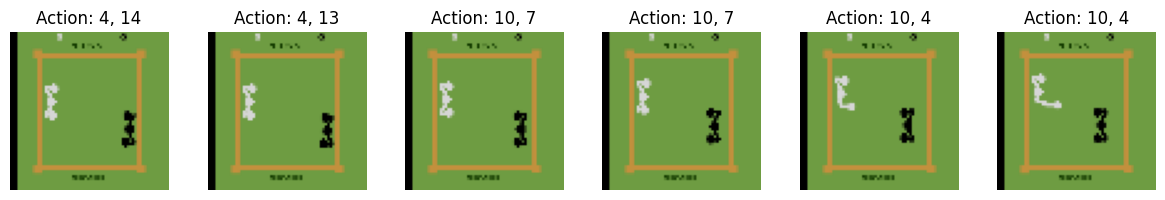

(0, 0)

In [14]:
frames = []
prev_actions = []

from collections import defaultdict

def env_loop(env_func, **kwargs):
    previous_actions_weight = kwargs.get('previous_actions_weight', 0.75)

    env = env_fn(env_func=env_func)
    observations, infos = env.reset()
    memory = defaultdict(list)

    while env.agents:
        actions = {}
        for agent in env.agents:
            if len(memory[agent]) > 0 and random.random() < previous_actions_weight:
                actions[agent] = memory[agent][-1]
            else:
                actions[agent] = env.action_space(agent).sample()

        for agent, action in actions.items():
            memory[agent].append(action)
        
        observations, rewards, terminations, truncations, infos = env.step(actions)
        yield observations, actions
    env.close()


n_cols = 6
n_rows = 1

iters = env_loop(env_func=get_env_from_id("boxing"), previous_actions_weight=0.5, num_actions=18)
offset = random.randint(0, 100)
for _ in range(offset):
    next(iters)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))

for i in range(n_cols):
    frame, action = next(iters)

    axs[i].imshow(frame['first_0'])
    axs[i].set_title(f"Action: {action['first_0']}, {action['second_0']}")
    axs[i].axis("off")

plt.tight_layout()
plt.show()

len(frames), len(prev_actions)

In [15]:
import random
import torch

class AtariDataset(Dataset):
    def __init__(self, seq_length: int, sequence_per_episode: int = 500):
        self.seq_length = seq_length
        self.dataset = None
        self.sequence_per_episode = sequence_per_episode

    def __len__(self):
        if self.dataset is None:
            return 0
        return len(self.dataset)
    
    def __getitem__(self, idx):
        if self.dataset is None:
            return None
        
        frames = self.dataset[idx]['frames']
        prev_actions = self.dataset[idx]['prev_actions']

        return frames, prev_actions
    
    def _to_tensor(self, x):
        return torch.tensor(x, device='cuda').div(255).mul(2).sub(1).permute(0, 3, 1, 2).contiguous()
    
    def collect_dataset(self, env_loop_func, episodes:int=1000, progress_bar:bool=False):
        self.dataset = []
        if progress_bar:
            pbar = tqdm(total=episodes)
        else:
            pbar = None


        for _ in range(episodes):
            if pbar is not None:
                pbar.update(1)
            env_loop = iter(env_loop_func()) 

            frames = []
            prev_actions = [[], []]

            current = 0
            num_appended = 0
            random_start = random.randint(0, 500)

            for observations, actions in env_loop:
                if num_appended >= self.sequence_per_episode:
                    break
                
                if current < random_start:
                    current += 1
                    continue

                frames.append(observations['first_0'])

                prev_actions[0].append(actions['first_0'])
                prev_actions[1].append(actions['second_0'])
                # prev_actions.append([actions['first_0'], actions['second_0']])

                if len(frames) >= self.seq_length:
                    self.dataset.append({
                        'frames': self._to_tensor(frames),
                        'prev_actions': torch.tensor(prev_actions, dtype=torch.long)
                    })
                    
                    frames = []
                    prev_actions = [[], []]

                    num_appended += 1
                current += 1


In [5]:
train_dataset = AtariDataset(seq_length=4, sequence_per_episode=10)
train_dataset.collect_dataset(
    lambda: env_loop(
        env_func=get_env_from_id("boxing"), 
        previous_actions_weight=0.65
    ),
    episodes=10,
    progress_bar=True
)

  0%|          | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_160972/3993550092.py:25: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  return torch.tensor(x, device='cuda').div(255).mul(2).sub(1).permute(0, 3, 1, 2).contiguous()
100%|██████████| 10/10 [00:08<00:00,  1.19it/s]


In [7]:
iters = iter(train_dataset)
data = next(iters)

In [9]:
data = next(iters)
data[1].shape

torch.Size([2, 4])

# Model

In [16]:
from dataclasses import dataclass
from typing import Optional

import torch
from torch import Tensor
import torch.nn as nn
import torch.nn.functional as F

# from models.diffusion.inner_model import InnerModel, InnerModelConfig

from dataclasses import dataclass
from typing import List, Optional

import torch
from torch import Tensor
import torch.nn as nn
import torch.nn.functional as F

from models.blocks import Conv3x3, FourierFeatures, GroupNorm, UNet

class AttentionPooling(nn.Module):
    def __init__(self, embed_dim=64, out_dim=256):
        super().__init__()
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.encoder = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=4, batch_first=True)
        self.proj = nn.Linear(embed_dim, out_dim)

    def forward(self, x):
        B = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)  # (B, 1, 64)
        x = torch.cat([cls, x], dim=1)         # (B, 9, 64)
        x = self.encoder(x)                    # (B, 9, 64)
        cls_out = x[:, 0]                      # (B, 64)
        return self.proj(cls_out)              # (B, 256)

@dataclass
class InnerModelConfig:
    img_channels: int
    num_steps_conditioning: int
    cond_channels: int
    depths: List[int]
    channels: List[int]
    attn_depths: List[bool]
    num_actions: Optional[int] = None


class InnerModel(nn.Module):
    def __init__(self, cfg: InnerModelConfig) -> None:
        super().__init__()
        self.noise_emb = FourierFeatures(cfg.cond_channels)
    
        
        self.act_emb = nn.Sequential(
            nn.Embedding(cfg.num_actions, cfg.cond_channels // cfg.num_steps_conditioning),
        )
        self.attention_pooling = AttentionPooling(embed_dim=cfg.cond_channels // cfg.num_steps_conditioning, out_dim=cfg.cond_channels)

        self.cond_proj = nn.Sequential(
            nn.Linear(cfg.cond_channels, cfg.cond_channels),
            nn.SiLU(),
            nn.Linear(cfg.cond_channels, cfg.cond_channels),
        )
        self.conv_in = Conv3x3((cfg.num_steps_conditioning + 1) * cfg.img_channels, cfg.channels[0])

        self.unet = UNet(cfg.cond_channels, cfg.depths, cfg.channels, cfg.attn_depths)

        self.norm_out = GroupNorm(cfg.channels[0])
        self.conv_out = Conv3x3(cfg.channels[0], cfg.img_channels)
        nn.init.zeros_(self.conv_out.weight)

    def forward(self, noisy_next_obs: Tensor, c_noise: Tensor, obs: Tensor, act: Tensor) -> Tensor:
        action_emb = self.act_emb(act) # [b, p, t, D]
        x1, x2 = action_emb[:, 0], action_emb[:, 1]  # [b, t, D]
        x = torch.cat([x1, x2], dim=1)  # [b, 2t, D]
        x = self.attention_pooling(x)

        cond = self.cond_proj(self.noise_emb(c_noise) + x)
        x = self.conv_in(torch.cat((obs, noisy_next_obs), dim=1))
        x, _, _ = self.unet(x, cond)
        x = self.conv_out(F.silu(self.norm_out(x)))
        return x


def add_dims(input: Tensor, n: int) -> Tensor:
    return input.reshape(input.shape + (1,) * (n - input.ndim))


@dataclass
class Conditioners:
    c_in: Tensor
    c_out: Tensor
    c_skip: Tensor
    c_noise: Tensor


@dataclass
class SigmaDistributionConfig:
    loc: float
    scale: float
    sigma_min: float
    sigma_max: float


@dataclass
class DenoiserConfig:
    inner_model: InnerModelConfig
    sigma_data: float
    sigma_offset_noise: float


class Denoiser(nn.Module):
    def __init__(self, cfg: DenoiserConfig) -> None:
        super().__init__()
        self.cfg = cfg
        self.inner_model = InnerModel(cfg.inner_model)
        self.sample_sigma_training = None

    @property
    def device(self) -> torch.device:
        return self.inner_model.noise_emb.weight.device

    def setup_training(self, cfg: SigmaDistributionConfig) -> None:
        assert self.sample_sigma_training is None

        def sample_sigma(n: int, device: torch.device):
            s = torch.randn(n, device=device) * cfg.scale + cfg.loc
            return s.exp().clip(cfg.sigma_min, cfg.sigma_max)

        self.sample_sigma_training = sample_sigma

    def apply_noise(self, x: Tensor, sigma: Tensor, sigma_offset_noise: float) -> Tensor:
        b, c, _, _ = x.shape
        offset_noise = sigma_offset_noise * torch.randn(b, c, 1, 1, device=self.device)
        return x + offset_noise + torch.randn_like(x) * add_dims(sigma, x.ndim)

    def compute_conditioners(self, sigma: Tensor) -> Conditioners:
        sigma = (sigma**2 + self.cfg.sigma_offset_noise**2).sqrt()
        c_in = 1 / (sigma**2 + self.cfg.sigma_data**2).sqrt()
        c_skip = self.cfg.sigma_data**2 / (sigma**2 + self.cfg.sigma_data**2)
        c_out = sigma * c_skip.sqrt()
        c_noise = sigma.log() / 4
        return Conditioners(*(add_dims(c, n) for c, n in zip((c_in, c_out, c_skip, c_noise), (4, 4, 4, 1, 1))))

    def compute_model_output(self, noisy_next_obs: Tensor, obs: Tensor, act: Tensor, cs: Conditioners) -> Tensor:
        rescaled_obs = obs / self.cfg.sigma_data
        rescaled_noise = noisy_next_obs * cs.c_in
        return self.inner_model(rescaled_noise, cs.c_noise, rescaled_obs, act)

    @torch.no_grad()
    def wrap_model_output(self, noisy_next_obs: Tensor, model_output: Tensor, cs: Conditioners) -> Tensor:
        d = cs.c_skip * noisy_next_obs + cs.c_out * model_output
        # Quantize to {0, ..., 255}, then back to [-1, 1]
        d = d.clamp(-1, 1).add(1).div(2).mul(255).byte().div(255).mul(2).sub(1)
        return d

    @torch.no_grad()
    def denoise(self, noisy_next_obs: Tensor, sigma: Tensor, obs: Tensor, act: Tensor) -> Tensor:
        cs = self.compute_conditioners(sigma)
        model_output = self.compute_model_output(noisy_next_obs, obs, act, cs)
        denoised = self.wrap_model_output(noisy_next_obs, model_output, cs)
        return denoised

    def forward(self, prev_actions: Tensor, frames: Tensor):
        n = self.cfg.inner_model.num_steps_conditioning
        seq_length = frames.size(1) - n

        all_obs = frames.clone()
        loss = 0

        for i in range(seq_length):
            obs = all_obs[:, i : n + i]
            next_obs = all_obs[:, n + i]
            act = prev_actions[:, :, i : n + i] # B, p, s

            # OLD (Diamond)
            # mask = batch.mask_padding[:, n + i]

            b, t, c, h, w = obs.shape 
            obs = obs.reshape(b, t * c, h, w)

            sigma = self.sample_sigma_training(b, self.device)
            noisy_next_obs = self.apply_noise(next_obs, sigma, self.cfg.sigma_offset_noise)

            cs = self.compute_conditioners(sigma)
            model_output = self.compute_model_output(noisy_next_obs, obs, act, cs)

            target = (next_obs - cs.c_skip * noisy_next_obs) / cs.c_out
            
            # loss += F.mse_loss(model_output[mask], target[mask]) # OLD (Diamond)
            loss += F.mse_loss(model_output, target)

            denoised = self.wrap_model_output(noisy_next_obs, model_output, cs)
            all_obs[:, n + i] = denoised

        loss /= seq_length
        return loss, {"loss_denoising": loss.detach()}

In [17]:
with open("/home/monsh/works/image/madx/madx/config/trainer.yaml", "r") as f:
    cfg = yaml.safe_load(f)
    cfg['agent']['denoiser']['inner_model']['num_actions'] = 18

cfg = OmegaConf.structured(cfg)

In [18]:
denoiser = Denoiser(cfg.agent.denoiser).to("cuda:0")
denoiser.setup_training(OmegaConf.structured(cfg.agent.denoiser.sigma_distribution))

# Training

In [ ]:
import wandb
wandb.login()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: monshinawatra. Use `wandb login --relogin` to force relogin


True

In [20]:
import torch
from utils import (get_lr_sched, configure_opt, broadcast_if_needed, keep_agent_copies_every)

def build_opt(model, cfg) -> torch.optim.AdamW:
    return configure_opt(model, **cfg.optimizer)

def build_lr_sched(opt, cfg) -> torch.optim.lr_scheduler.LambdaLR:
    return get_lr_sched(opt, num_warmup_steps=cfg.training.lr_warmup_steps)

In [10]:

# # opt = build_opt(denoiser, cfg)
# # lr_sched = build_lr_sched(opt, cfg)
# opt = torch.optim.AdamW(
#     denoiser.parameters(),
#     lr=1e-4,
#     weight_decay=1e-2,
# )

# lr_sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
#     opt,
#     T_0=200,
#     T_mult=1,
#     eta_min=1e-6,
# )

# lr = []
# for epoch in range(1000):
#     lr_sched.step()
#     lr.append(opt.param_groups[0]['lr'])

# plt.plot(lr)
# plt.title("Learning Rate")
# plt.xlabel("Steps")
# plt.ylabel("Learning Rate")
# plt.show()

In [22]:
from torch.utils.data import DataLoader
import torch.optim.lr_scheduler as lr_scheduler

game_id = "boxing"
# num_epochs = 100

max_steps = 100_000
reset_dataset_every = 5_000

previous_actions_weight_scheduler = np.linspace(0.75, 0.3, max_steps // reset_dataset_every)
episodes_per_collect = 20
sequence_per_episode = 150
batch_size = 32

# opt = build_opt(denoiser, cfg)
opt = torch.optim.AdamW(
    denoiser.parameters(),
    lr=1e-4,
    weight_decay=1e-2,
)

# # lr_sched = build_lr_sched(opt, cfg)
lr_sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    opt,
    T_0=reset_dataset_every,
    T_mult=1,
    eta_min=1e-6,
)

train_dataset = AtariDataset(seq_length=5, sequence_per_episode=sequence_per_episode)
to_log = []

exp_name = "nagent-attention-pooling"
run = wandb.init(
    project="madx",  # Specify your project
    name=exp_name,
    config={                        # Track hyperparameters and metadata
        "max_steps": max_steps,
        "batch_size": batch_size,
        "episodes_per_collect": episodes_per_collect,
        "sequence_per_episode": sequence_per_episode,
        "max_previous_actions_weight": 0.75,
        "min_previous_actions_weight": 0.30,
        "reset_dataset_every": reset_dataset_every,
    },
)

wandb: WARNING Unable to render HTML, can't import display from ipython.core


wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


In [ ]:
steps = 0

train_dataset.collect_dataset(
    lambda: env_loop(
        env_func=get_env_from_id(game_id), 
        previous_actions_weight=previous_actions_weight_scheduler[0]
    ),     
    episodes=episodes_per_collect,
    progress_bar=True
)
data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
iters = iter(data_loader)

with tqdm(total=max_steps) as pbar:
    log_template = "Steps {steps}/{max_steps}: {task}"
    while steps < max_steps:
        if steps % reset_dataset_every == 0 and steps > 0:
            pbar.set_description(log_template.format(steps=steps, max_steps=max_steps, task="Collecting dataset"))
            train_dataset.collect_dataset(
                lambda: env_loop(
                    env_func=get_env_from_id(game_id), 
                    previous_actions_weight=previous_actions_weight_scheduler[steps // reset_dataset_every]
                ),     
                episodes=episodes_per_collect,
                progress_bar=False
            )
            data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            iters = iter(data_loader)

        denoiser.train()
        try:
            batch = next(iters)
        except StopIteration:
            iters = iter(data_loader)
            batch = next(iters)

        # for batch in data_loader:
        if steps >= max_steps:
            break
        
        steps += 1
        pbar.set_description(log_template.format(steps=steps, max_steps=max_steps, task="Training"))
        pbar.update(1)

        opt.zero_grad()
        frames, prev_actions = batch
        prev_actions = prev_actions.to("cuda:0")
        frames = frames.to("cuda:0")

        loss, metrics = denoiser(prev_actions, frames)
        loss.backward()

        opt.step()
        opt.zero_grad()

        lr_sched.step()
        wandb.log({"lr": opt.param_groups[0]['lr'], "loss": loss.item(), "actions_weight": previous_actions_weight_scheduler[steps // reset_dataset_every]})

        if steps % reset_dataset_every == 0:
            torch.save(denoiser.state_dict(), f"weights/{exp_name}-{steps:06d}.pt")

wandb.finish()

  0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_313584/3993550092.py:25: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  return torch.tensor(x, device='cuda').div(255).mul(2).sub(1).permute(0, 3, 1, 2).contiguous()
Steps 92/100000: Training:   0%|          | 92/100000 [00:10<5:06:59,  5.42it/s]

# Play

In [24]:
# checkpoint = torch.load("/home/monsh/works/image/madx/madx/Boxing.pt")
# denoiser_state_dict = {k.replace("denoiser.", ""): v for k, v in checkpoint.items() if k.startswith("denoiser.")}

with open("/home/monsh/works/image/madx/madx/config/trainer.yaml", "r") as f:
    cfg = yaml.safe_load(f)
    # config = config['denoiser']

    # For boxing
    cfg['agent']['denoiser']['inner_model']['num_actions'] = 18
    cfg['agent']['actor_critic']['num_actions'] = 18

cfg = OmegaConf.structured(cfg)

In [31]:
from pathlib import Path

checkpoint = torch.load("from_scratch_0100.pt")
denoiser = Denoiser(cfg.agent.denoiser).to("cuda:0")
denoiser.load_state_dict(checkpoint)

# Diamond
# denoiser.load_state_dict(torch.load(_path_ckpt_dir / f"denoiser_{10:04d}.pt"))
# denoiser.load_state_dict(denoiser_state_dict)

/tmp/ipykernel_31674/1034986674.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("from_scratch_0100.pt")


<All keys matched successfully>

In [14]:
from models.diffusion import Denoiser, DiffusionSampler, DiffusionSamplerConfig

sampler = DiffusionSampler(
    denoiser=denoiser,
    cfg=DiffusionSamplerConfig(
        num_steps_denoising=3
    ),
),

  0%|          | 0/11 [00:00<?, ?it/s]

tensor([[226, 318, 112, 114]], device='cuda:0')


 27%|██▋       | 3/11 [00:00<00:00,  8.78it/s]

tensor([[318, 112, 114, 105]], device='cuda:0')
tensor([[112, 114, 105, 121]], device='cuda:0')
tensor([[114, 105, 121,  90]], device='cuda:0')
tensor([[105, 121,  90,  14]], device='cuda:0')


 64%|██████▎   | 7/11 [00:00<00:00, 12.81it/s]

tensor([[121,  90,  14,  13]], device='cuda:0')
tensor([[90, 14, 13, 32]], device='cuda:0')
tensor([[14, 13, 32, 68]], device='cuda:0')


 82%|████████▏ | 9/11 [00:00<00:00, 13.66it/s]

tensor([[ 13,  32,  68, 122]], device='cuda:0')
tensor([[ 32,  68, 122, 303]], device='cuda:0')
tensor([[ 68, 122, 303, 321]], device='cuda:0')


100%|██████████| 11/11 [00:00<00:00, 12.01it/s]


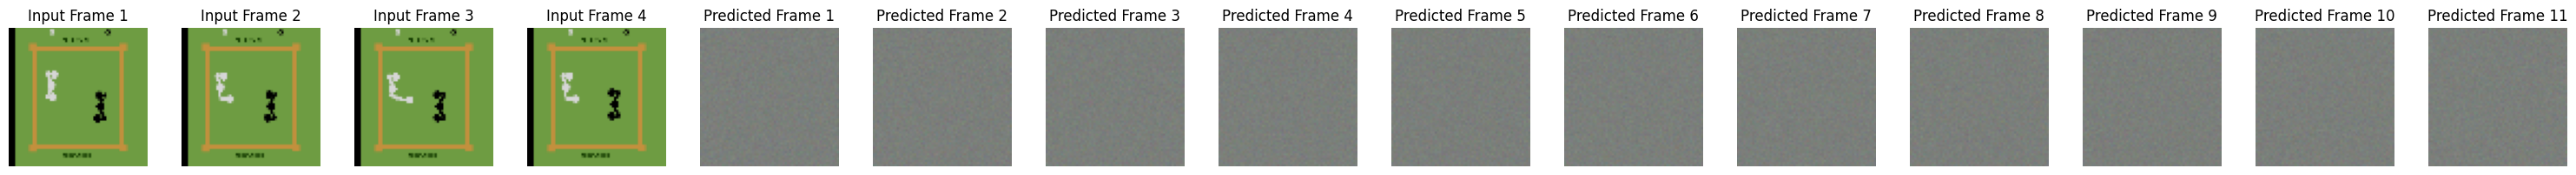

In [16]:
import random
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from tqdm import tqdm


def _to_tensor(x):
    return torch.tensor(x, device='cuda').div(255).mul(2).sub(1).permute(2, 0, 1).contiguous()



# obs, info = env.reset()

# for i in range(1000):
#     if i < random_start:
#         action = 0
#     else:
#         action = env.action_space.sample()

#     obs, reward, terminated, truncated, info = env.step(action)
#     if i < random_start:
#         continue

#     if len(actions) < seq:
#         frames.append(obs)
#         # break
#     actions.append(action)

#     if terminated or truncated:
#         obs, info = env.reset()



def get_env_from_id(id: str):
    if id == "boxing":
        from pettingzoo.atari import boxing_v2
        return boxing_v2.parallel_env
    
    else:
        raise ValueError(f"Environment {id} not found")


from supersuit import frame_skip_v0, resize_v1, frame_stack_v1, reshape_v0

def env_fn(env_func):
    env = env_func(render_mode="rgb_array")
    env = frame_skip_v0(env, num_frames=4)
    env = resize_v1(env, x_size=64, y_size=64)

    return env


seq = 4

frames = []
actions = []

random_start = random.randint(0, 500)

env = env_fn(env_func=get_env_from_id("boxing"))
observations, infos = env.reset()

i = 0
while env.agents:
    act = {}
    for agent in env.agents:
        # if i < random_start:
        #     act[agent] = env.action_space(agent).sample()
        # else:
        #     # action = env.action_space.sample()
        act[agent] = env.action_space(agent).sample()
    
    observations, rewards, terminations, truncations, infos = env.step(act)
    i += 1
    if i < random_start:
        continue

    if len(actions) < seq:
        frames.append(observations['first_0'])

    actions.append(act['first_0'] * 18 + act['second_0'])

    # if terminations or truncations:
    #     truncations, infos = env.reset()

    if len(actions) > 50:
        break

actions_tensor = torch.tensor(actions, dtype=torch.long).to("cuda:0")
for current_frame in tqdm(range(11)):
    frames_tensor = [_to_tensor(frame) for frame in frames[current_frame: current_frame+seq]]
    frames_tensor = torch.stack(frames_tensor).to("cuda:0")

    # Convert actions to tensor
    x = frames_tensor.unsqueeze(0)
    act = actions_tensor[current_frame: current_frame+seq].unsqueeze(0)
    print(act)
    out = sampler[0].sample(x, act)

    img = Image.fromarray(out[0][0].add(1).div(2).mul(255).byte().permute(1, 2, 0).cpu().numpy())
    pygame_image = np.array(img.resize((64, 64), resample=Image.NEAREST))#.transpose((1, 0, 2))
    frames.append(pygame_image)


n_cols = len(frames)
n_rows = 1

fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))

for i in range(n_cols):
    # axs[i].imshow(frames[i])
    axs[i].imshow(frames[i])
    axs[i].axis("off")
    if i < seq:
        title = f"Input Frame {i+1}"
    else:
        title = f"Predicted Frame {i+1-seq}"

    axs[i].set_title(title)


plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import imageio
from io import BytesIO

# === CONFIG ===
seq = 4  # Number of input frames (rest are predictions)
fps = 2  # Frames per second in the GIF
gif_path = "output_animation_with_titles_loop.gif"

# Convert torch tensors to numpy arrays (if needed)
frames_np = [frame.cpu().numpy().transpose(1, 2, 0) if hasattr(frame, 'cpu') else frame for frame in frames]
frames_np = [(frame * 255).astype(np.uint8) if frame.max() <= 1.0 else frame.astype(np.uint8) for frame in frames_np]

# === GENERATE TITLED FRAMES ===
titled_frames = []
for i, frame in enumerate(frames_np):
    fig, ax = plt.subplots()
    ax.imshow(frame)
    ax.axis("off")

    # Add title
    if i < seq:
        ax.set_title(f"Input Frame {i+1}", fontsize=12)
    else:
        ax.set_title(f"Predicted Frame {i+1-seq}", fontsize=12)

    # Save figure to buffer
    buf = BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0.1)
    buf.seek(0)
    titled_frame = imageio.v3.imread(buf)
    titled_frames.append(titled_frame)
    plt.close(fig)

# === SAVE TO GIF with LOOP ===
imageio.mimsave(gif_path, titled_frames, fps=fps, loop=0)
print(f"Looping GIF saved to: {gif_path}")


Looping GIF saved to: output_animation_with_titles_loop.gif
